<a href="https://colab.research.google.com/github/vinechai/sreality_EDA/blob/main/02_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Predicting apartment sale prices in Prague

Author: Vitalii Nechai

Data: Scraped from sreality.cz (November 2024)

## Part 1: Data preparation, model estimation

### **1. Setup & Imports**

#### 1.1 Importing packages & setting-up parameters

In [48]:
# Standard libraries
import os
import sys
import time
import copy
import math

from time import time #  project timer


# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Sklearn (models & preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 250)

# Set random seed for reproducibility
SEED = 42

# Project paths
DATA_DIR = os.path.join("data")
RAW_FILE = os.path.join(DATA_DIR, "updated_apartments_praha.csv")



from IPython.display import display, HTML
import missingno as msno
import re



In [49]:
# parameters

#### 1.2 Starting project timer and exporting requirements

In [50]:
# Starting project timer
tic_all = time()

In [51]:
# save requirements
# pip freeze > requirements.txt
# Run it in your terminal/bash, not in the notebook:Do it after the project works end-to-end (data cleaning → training → app).

# alternatively
"""
# Collecting packages info and saving to requirements.txt file
session_info.show(cpu = True, std_lib = True, dependencies = True, write_req_file = True,
                  req_file_name = 'requirements.txt')
"""

"\n# Collecting packages info and saving to requirements.txt file\nsession_info.show(cpu = True, std_lib = True, dependencies = True, write_req_file = True,\n                  req_file_name = 'requirements.txt')\n"

#### 1.3 Importing and inspecting source data

In [52]:
# Loading data from google drive

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Provide the full path to the file in Google Drive
file_path = '/content/drive/My Drive/Colab Notebooks/updated_apartments_praha.csv'

# Load the CSV file using pandas
# data = pd.read_csv(file_path)

data_raw = pd.read_csv(file_path)  # load original
data = data_raw.copy()  # working dataset

Mounted at /content/drive


In [53]:
# Loading data from repo data folder
# data_raw = pd.read_csv(RAW_FILE)
# data = data_raw.copy()

In [54]:
#set max columns and rows
pd.set_option('display.max_columns', data.shape[1])
pd.set_option('display.max_rows', None)

In [55]:
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (4609, 71)


,Location,Size,Price (CZK),Link,Total price,Order ID,Update,Building,Property status,Ownership,Property location,Floor,Usable area,Floorage,Balcony,Move-in date,Water,Heating,Gas,Electricity,Transportation,Energy Performance Rating,Energy Performance Certificate,Loft,Furnished,Elevator,Flat type,Terrace,Cellar,Parking,Energy Performance Indicator,Price,Garden area,Cost of living,Garage,Barrier-free access,Loggia,Reconstruction year,Waste,Telecommunications,Annuity,Acquisition of title,Final building approval year,Road,Built-up area,Construction completion date,Note on the price,ID,Discounted,Original cost,Sales commencement date,Visit site date,Visit site date to,Basin area,Basin,Status,Ceiling height,Share size,Number of owners,Starting price,Expert judgement,Minimum Bid,Auction principal,Type of auction,Venue auction,Auction sale date,1st site visit date,2nd site visit date,Advertisement of auction,Number of flats,Share size of common area
0,"Hlučkova, Praha 9 - Letňany",For sale apartment 2+kt 48 m²,7700000,https://www.sreality.cz/en/detail/sale/flat/2+kt/praha-letnany-hluckova/2482689356,7 700 000 CZK per property,N1021,Yesterday,Brick,New homes,Personal,Quiet part of municipality,1. floor of total 4 including 2 underground,48 m2,48 m2,NaN,Immediately,Water supply,Central district heating,NaN,230 V,"Road, Urban public transportation, Bus",Class G,NaN,NaN,Partially,NaN,NaN,41 m2,4 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Zakšínská, Praha 9 - Střížkov",For sale apartment 3+kt 98 m²,11899000,https://www.sreality.cz/en/detail/sale/flat/3+kt/praha-strizkov-zaksinska/4054574412,11 899 000 CZK per property (k jednání),N1013,Yesterday,Brick,New homes,Personal,Quiet part of municipality,6. floor of total 7 including 1 underground,98 m2,103 m2,NaN,Immediately,Water supply,Central district heating,NaN,NaN,"Highway, Road, Urban public transportation, Bus",Class G,NaN,NaN,NaN,NaN,NaN,NaN,6 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4 m2,NaN,NaN,"Internet, Cable TV",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Hlučkova, Praha 9 - Letňany",For sale apartment 2+kt 45 m²,7700000,https://www.sreality.cz/en/detail/sale/flat/2+kt/praha-letnany-hluckova/2918896972,7 700 000 CZK per property,N1022,Yesterday,Brick,New homes,Personal,Quiet part of municipality,1. floor of total 4 including 2 underground,45 m2,45 m2,NaN,Immediately,Water supply,Central district heating,NaN,230 V,"Train, Road, Urban public transportation, Bus",Class G,NaN,NaN,Partially,NaN,NaN,42 m2,3 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Musílkova, Praha 5 - Košíře",For sale apartment 3+kt 106 m² (Attic),11490000,https://www.sreality.cz/en/detail/sale/flat/3+kt/praha-kosire-musilkova/734487884,11 490 000 CZK per property (k jednání),N1062,Yesterday,Brick,In very good condition,Personal,Busy part of municipality,6. floor of total 6 including 1 underground,106 m2,100 m2,6 m2,Immediately,Water supply,Local gas,Gas pipeline,230 V,"Road, Urban public transportation, Bus",Class E Coll. 78/2013 complying with,Open Energy Performance Certificate,NaN,Partially,NaN,Attic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Kováříkova, Praha 5 - Hlubočepy",For sale apartment 3+kt 71 m²,12990000,https://www.sreality.cz/en/detail/sale/flat/3+kt/praha-hlubocepy-kovarikova/4141741388,12 990 000 CZK per property,N1005,Yesterday,Brick,In very good condition,Personal,Quiet part of municipality,1. floor of total 5 including 1 underground,71 m2,71 m2,NaN,Immediately,NaN,NaN,NaN,NaN,NaN,Class C Coll. 78/2013 complying with,NaN,NaN,Partially,NaN,

In [56]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4609 entries, 0 to 4608
Data columns (total 71 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Location                        4609 non-null   object 
 1   Size                            4609 non-null   object 
 2   Price (CZK)                     4609 non-null   object 
 3   Link                            4609 non-null   object 
 4   Total price                     3941 non-null   object 
 5   Order ID                        3758 non-null   object 
 6   Update                          4250 non-null   object 
 7   Building                        4250 non-null   object 
 8   Property status                 4250 non-null   object 
 9   Ownership                       4250 non-null   object 
 10  Property location               1944 non-null   object 
 11  Floor                           4250 non-null   object 
 12  Usable area                     42

#### 1.4 Inspecting missing values

In [57]:
# Inspect missing values as percentages
missing_values = data.isnull().mean().mul(100).round(2)
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
display(missing_values)

,0
Loft,100.00
Barrier-free access,100.00
Elevator,100.00
Basin,100.00
Number of owners,99.98
2nd site visit date,99.98
Share size of common area,99.98
1st site visit date,99.98
Auction sale date,99.96
Expert judgement,99.96


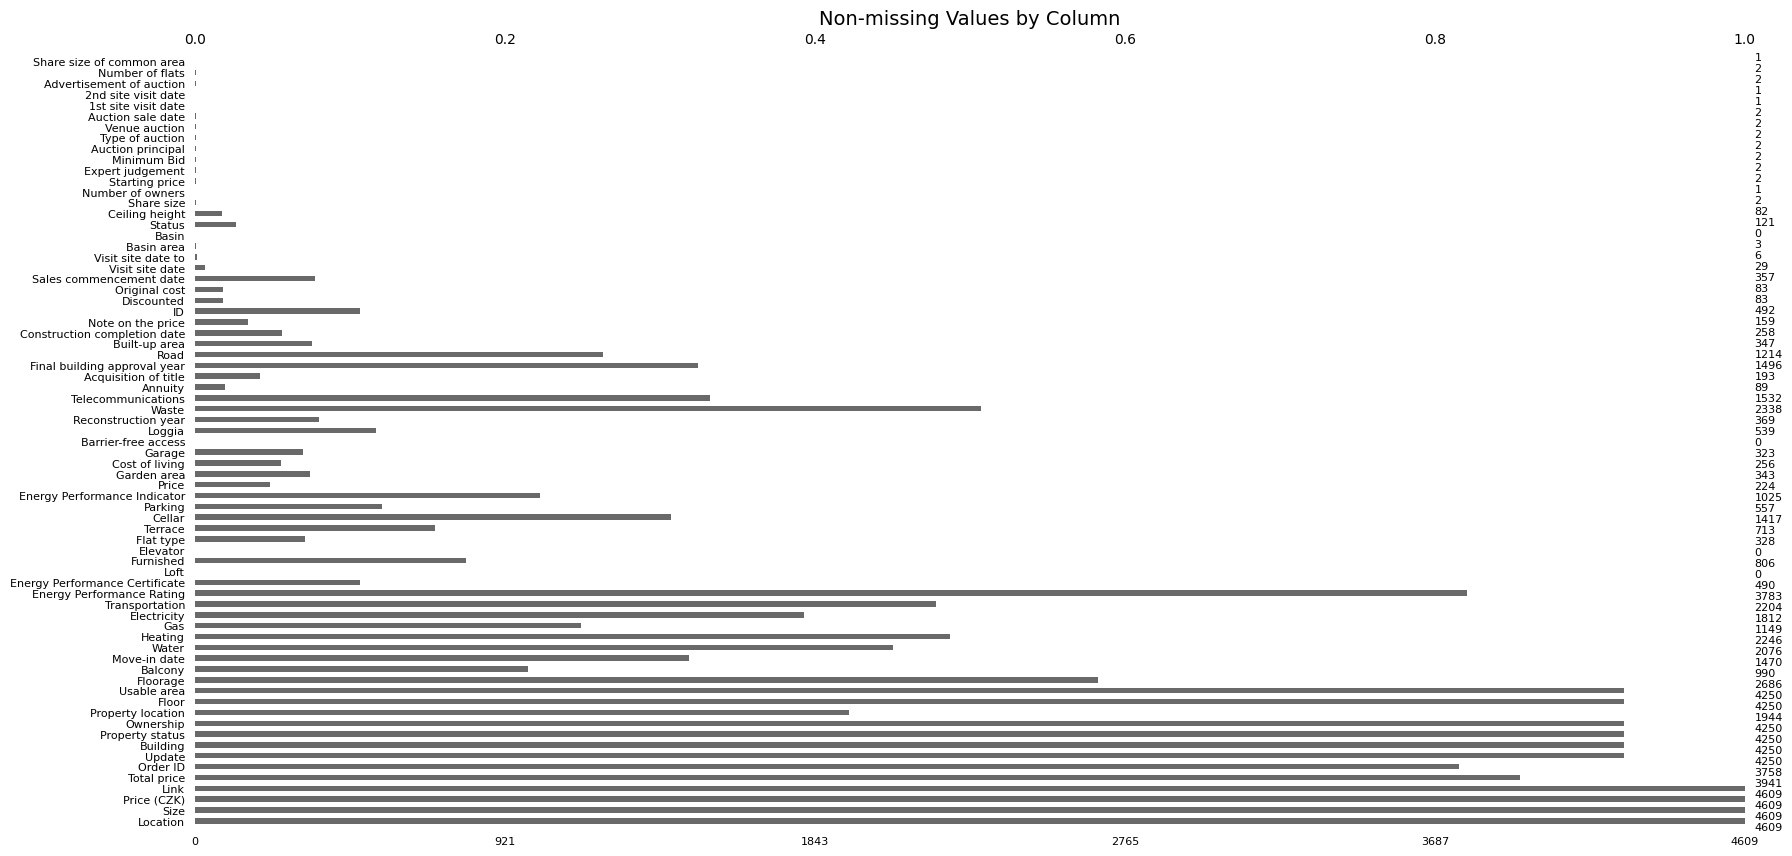

In [58]:
msno.bar(data, figsize=(20,10), fontsize=8)
plt.title("Non-missing Values by Column", fontsize=14)
plt.show()

### 2. Data Cleansing and Transformation

#### 2.1 Inspect basic variable information



For each variable, report:
- % of missing values
- number of unique values
- distribution of values

In [59]:
from IPython.display import display, HTML

for var in data.columns:
    dtype = data[var].dtype
    value_counts = pd.concat(
        [data[var].value_counts(dropna=False),
         data[var].value_counts(normalize=True, dropna=False).mul(100)],
        axis=1, keys=('counts', 'percentage')
    )

    print(f"\n\n{'='*40}\n"
          f"{var} (dtype: {dtype}) - {len(data[var].unique())} unique values\n"
          f"{'='*40}")
    display(HTML(value_counts.to_html()))



Location (dtype: object) - 1781 unique values


,counts,percentage
Location,,
"Hodkovická, Praha 4 - Kamýk",79,1.714038
"Waltariho, Praha 9 - Hloubětín",66,1.431981
"Hábova, Praha - Stodůlky",61,1.323498
"Kolbenova, Praha 9 - Vysočany",60,1.301801
"Wassermannova, Praha 5 - Hlubočepy",58,1.258407
"Komárkova, Praha 4 - Chodov",50,1.084834
Praha 9 - Kbely,34,0.737687
"Na vysoké I, Praha 5",33,0.715990
"Mladoboleslavská, Praha 9 - Kbely",30,0.650900




Size (dtype: object) - 1026 unique values


,counts,percentage
Size,,
For sale apartment 2+kt 52 m²,79,1.714038
For sale apartment 2+kt 49 m²,66,1.431981
For sale apartment 2+kt 55 m²,65,1.410284
For sale apartment 2+kt 53 m²,62,1.345194
For sale apartment 2+kt 47 m²,61,1.323498
For sale apartment 2+kt 45 m²,60,1.301801
For sale apartment 2+kt 54 m²,59,1.280104
For sale apartment 2+kt 46 m²,53,1.149924
For sale apartment 2+kt 43 m²,49,1.063137




Price (CZK) (dtype: object) - 2162 unique values


...

,counts,percentage
Advertisement of auction,,
NaN,4607,99.956607
View advertisement of auction,2,0.043393




Number of flats (dtype: float64) - 3 unique values


,counts,percentage
Number of flats,,
NaN,4607,99.956607
2.0,1,0.021697
30.0,1,0.021697




Share size of common area (dtype: object) - 2 unique values


,counts,percentage
Share size of common area,,
NaN,4608,99.978303
7346/341132,1,0.021697


#### 2.2 Column Names Cleaning

In [60]:
# Clean column names by converting to lowercase, replacing spaces, and stripping any leading/trailing spaces
data.columns = data.columns.str.lower().str.replace(' ', '_').str.strip()


#### 2.3 Target Variable Transformation

The dataset contains both 'price' and 'price_(czk)' columns. 'price' is a placeholder with inconsistent values, so we can drop it.
Steps:
- Drop the placeholder 'price'
- Rename 'price_(czk)' → 'price'
- Replace 'Information about price at agency' with NaN
- Convert column to numeric dtype

In [61]:
data = data.drop(columns=['price'])
data = data.rename(columns={'price_(czk)': 'price'})
data['price'] = data['price'].replace('Information about price at agency', np.nan)
data['price'] = pd.to_numeric(data['price'], errors='coerce')

 A second column 'total_price' exists; we will later decide whether it should replace 'price' as the target variable.




#### 2.4 Remove Irrelevant Columns

In this step, we remove columns from the dataset that are irrelevant, contain excessive missing values, or do not contribute meaningfully to our predictive modeling. Here is the rationale for each category of columns removed:

- Columns irrelevant to flat price prediction: Columns such as link, order_id, update, move-in_date, note_on_the_price, id, visit_site_date, visit_site_date_to, status, number_of_owners, 1st_site_visit_date, and 2nd_site_visit_date are administrative or logistical details that are unrelated to property pricing and do not provide valuable information for model training.

- Columns with only NA values: Columns loft, elevator, barrier-free access, and basin contain only NA values across all entries and thus provide no information for analysis.

- Columns likely irrelevant due to location: Since all listings are within Prague, major infrastructure and amenities such as telecommunications and road are consistently available and do not vary meaningfully across listings. As a result, they are unlikely to influence pricing and will be removed.

- Columns likely containing data entry errors: The number_of_flats column includes values that appear inconsistent with realistic values for individual flat listings (e.g., "30" flats in a single entry), suggesting it is likely a data entry error. We exclude this column to avoid introducing noise.

- Columns specific to auction listings: Columns related to auctions (starting_price, expert_judgement, minimum_bid, auction_principal, type_of_auction, venue_auction, auction_sale_date, advertisement_of_auction) are specific to only two listings in the dataset. Including these specialized columns would add unnecessary sparsity without significantly enhancing our model's performance, so they are removed.

In [62]:
# MANUAL_INPUT
# Columns to be dropped
columns_to_drop = [
    'link', 'order_id', 'update', 'move-in_date', 'note_on_the_price', 'id',
    'visit_site_date', 'visit_site_date_to', 'status', 'number_of_owners',
    '1st_site_visit_date', '2nd_site_visit_date', 'loft', 'elevator',
    'barrier-free_access', 'basin', 'telecommunications', 'road', 'number_of_flats',
    'starting_price', 'expert_judgement', 'minimum_bid', 'auction_principal',
    'type_of_auction', 'venue_auction', 'auction_sale_date', 'advertisement_of_auction',
    'original_cost'
]

data = data.drop(columns=columns_to_drop)


In [63]:
# Print basic info about variables: % of missing, # of unique values, unique values in data
for var in data.columns:
    dtype = data[var].dtype  # Get the data type of the column
    value_counts = pd.concat(
        [data[var].value_counts(dropna=False),
         data[var].value_counts(normalize=True, dropna=False).mul(100)],
        axis=1, keys=('counts', 'percentage')
    )
    # Print variable name with data type and number of unique values
    print(f"\n\n{'='*40}\n{var} (dtype: {dtype}) - {len(data[var].unique())} unique values\n{'='*40}")

    # Display the table with counts and percentages
    display(HTML(value_counts.to_html()))




location (dtype: object) - 1781 unique values


,counts,percentage
location,,
"Hodkovická, Praha 4 - Kamýk",79,1.714038
"Waltariho, Praha 9 - Hloubětín",66,1.431981
"Hábova, Praha - Stodůlky",61,1.323498
"Kolbenova, Praha 9 - Vysočany",60,1.301801
"Wassermannova, Praha 5 - Hlubočepy",58,1.258407
"Komárkova, Praha 4 - Chodov",50,1.084834
Praha 9 - Kbely,34,0.737687
"Na vysoké I, Praha 5",33,0.715990
"Mladoboleslavská, Praha 9 - Kbely",30,0.650900




size (dtype: object) - 1026 unique values


,counts,percentage
size,,
For sale apartment 2+kt 52 m²,79,1.714038
For sale apartment 2+kt 49 m²,66,1.431981
For sale apartment 2+kt 55 m²,65,1.410284
For sale apartment 2+kt 53 m²,62,1.345194
For sale apartment 2+kt 47 m²,61,1.323498
For sale apartment 2+kt 45 m²,60,1.301801
For sale apartment 2+kt 54 m²,59,1.280104
For sale apartment 2+kt 46 m²,53,1.149924
For sale apartment 2+kt 43 m²,49,1.063137




price (dtype: float64) - 2162 unique values


...

,counts,percentage
ceiling_height,,
NaN,4527,98.220872
3.0 m,12,0.260360
2.65 m,11,0.238663
2.8 m,10,0.216967
2.5 m,7,0.151877
2.7 m,7,0.151877
2.6 m,6,0.130180
3.8 m,5,0.108483
4.0 m,2,0.043393




share_size (dtype: object) - 3 unique values


,counts,percentage
share_size,,
NaN,4607,99.956607
1/2,1,0.021697
3/8,1,0.021697




share_size_of_common_area (dtype: object) - 2 unique values


,counts,percentage
share_size_of_common_area,,
NaN,4608,99.978303
7346/341132,1,0.021697


### 2.5 Basic Data transofrmation

##### 2.5.1 Cleaning 'total_price' and 'discounted'

 **Step 1.** We should get read of 'CZK per property' and 'CZK per property (k jednání)', and also conversion to EUR like here: 12 655 000 CZK (500 000 EUR) per property

In [64]:
# Extract numeric CZK values, remove spaces, convert to float
for col in ['total_price', 'discounted']:
    data[f"{col}_cleaned"] = (
        data[col]
        .str.extract(r'([\d\s]+) CZK')[0]  # Extract only the CZK price
        .str.replace(r'\s', '', regex=True)  # Remove spaces within the number
        .astype(float)  # Convert to numeric
    )

 **Step 2.** Now let's compare 'price' vs. 'total_price_cleaned' and see if there're any differences between them and which column should we drop.

In [65]:
# Drop rows where either is missing for fair comparison
tmp = data.dropna(subset=['price', 'total_price_cleaned']).copy()
tmp['difference'] = tmp['total_price_cleaned'] - tmp['price']

mismatches = tmp[tmp['difference'] != 0]
print(f"Found {len(mismatches)} mismatched rows "
      f"({len(mismatches)/len(tmp)*100:.1f}% of compared rows).")
print(mismatches[['price', 'total_price_cleaned', 'difference']])

Found 167 mismatched rows (4.2% of compared rows).
           price  total_price_cleaned  difference
49     8890000.0            9779000.0    889000.0
57     9999000.0            9799000.0   -200000.0
106   12310500.0           12990000.0    679500.0
107    6295000.0            7299000.0   1004000.0
150    8320500.0            8790000.0    469500.0
208   31950000.0           33390000.0   1440000.0
216    6050000.0            5999000.0    -51000.0
224   18190000.0           18390000.0    200000.0
267    8390000.0            8290000.0   -100000.0
313    7080000.0            6900000.0   -180000.0
317    6850000.0            6690000.0   -160000.0
342    7099000.0            6890000.0   -209000.0
343    7099000.0            6890000.0   -209000.0
350    7099000.0            6890000.0   -209000.0
351    7099000.0            6890000.0   -209000.0
353    8790000.0            8390000.0   -400000.0
396   12150000.0           12590000.0    440000.0
546    9570000.0            9400000.0   -170000.0

Observations:
1. Total Price Lower: In some cases, total_price_cleaned is lower than price. This could reflect:

- Adjustments made for discounts or negotiations.
- Exclusion of additional fees or costs that were included in the initial price.

2. Total Price Higher: In other cases, total_price_cleaned is higher. This might account for:

- Additional costs, such as VAT, real estate agency fees, or parking.
- Corrections to reflect the true advertised price.

3. Differences are Minor for Many Entries: For some rows, differences are as small as 1,000–50,000 CZK, which may represent rounding issues or minor edits in the listings.

4. Significant Discrepancies: There are a few extreme outliers where the difference is in the millions. These could indicate:

- Errors in data scraping or manual entry in the listings (one of the entries misses a digit in a 'price' column, so the difference between columns is 800%)


Choose price as Target:

- total_price_cleaned has around 15% of missing values, while price column has 5%. Since the differences between the columns are quite minimal the amount of missing values becomes a decisive factor for chosing target variable.

We need to drop 'total_price_cleaned' and 'total_price' columns

**Step 3.** Handle extreme outliers


In [66]:
tmp['percentage_diff'] = (tmp['difference'] / tmp['price']).mul(100)
extreme_outliers = tmp[abs(tmp['percentage_diff']) > 15]
display(extreme_outliers)

,location,size,price,total_price,building,property_status,ownership,property_location,floor,usable_area,floorage,balcony,water,heating,gas,electricity,transportation,energy_performance_rating,energy_performance_certificate,furnished,flat_type,terrace,cellar,parking,energy_performance_indicator,garden_area,cost_of_living,garage,loggia,reconstruction_year,waste,annuity,acquisition_of_title,final_building_approval_year,built-up_area,construction_completion_date,discounted,sales_commencement_date,basin_area,ceiling_height,share_size,share_size_of_common_area,total_price_cleaned,discounted_cleaned,difference,percentage_diff
107,"Pod Karlovem, Praha 2 - Vinohrady",For sale apartment 3+kt 101 m² (Mezonet),6295000.0,7 299 000 CZK per property,Brick,Renovated,Cooperative,NaN,6. floor of total 5 including 1 underground,101 m2,109 m2,NaN,Water supply,NaN,Gas pipeline,NaN,NaN,Class D Coll. 148/2007 complying with,NaN,NaN,Mezonet,NaN,1 m2,NaN,NaN,NaN,NaN,NaN,NaN,2023.0,Sewerage,16155000 Kč,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7299000.0,NaN,1004000.0,15.949166
1314,"Pod Karlovem, Praha - Vinohrady",For sale apartment 3+kt 99 m²,5340000.0,6 299 000 CZK per property,Brick,New development projects,Cooperative,NaN,2. floor,99 m2,106 m2,NaN,NaN,NaN,NaN,NaN,NaN,Class D Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,1 m2,1.0,147.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,15650000 Kč,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6299000.0,NaN,959000.0,17.958801
1454,"Pod Karlovem, Praha - Vinohrady",For sale apartment 2+kt 46 m²,2399000.0,2 899 000 CZK per property,Brick,Renovated,Cooperative,NaN,2. floor,46 m2,48 m2,NaN,Water supply,NaN,NaN,230 V,NaN,Class D Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,1 m2,1.0,147.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,7561000 Kč,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2899000.0,NaN,500000.0,20.842018
2743,"Hábova, Praha - Stodůlky",For sale apartment 1+kt 27 m²,4893960.0,5 649 650 CZK per property,Mixed,New homes,Personal,NaN,4. floor,34 m2,30 m2,4 m2,NaN,NaN,NaN,NaN,NaN,Class B Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,6 m2,NaN,67.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5649650.0,NaN,755690.0,15.441279
2760,"Kardašovská, Praha 9 - Hloubětín",For sale apartment 2+kt 39 m²,597767.0,5 977 667 CZK per property,Brick,New homes,Personal,NaN,3. floor of total 8 including 1 underground,39 m2,NaN,9 m2,Water supply,Central district heating,NaN,"230 V, 400 V","Highway, Road, Urban public transportation, Bus",Class B,NaN,NaN,NaN,NaN,3 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sewerage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5977667.0,NaN,5379900.0,899.999498
3092,"Kardausova, Praha 10 - Dolní Měcholupy",For sale apartment 2+kt 50 m²,9290000.0,2 890 000 CZK per property,Mixed,New homes,Cooperative,Quiet part of municipality,4. floor of total 5,50 m2,50 m2,NaN,Water supply,NaN,NaN,"230 V, 400 V",NaN,Class G,NaN,NaN,NaN,43 m2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sewerage,NaN,NaN,2024.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2890000.0,NaN,-6400000.0,-68.891281
3417,"Hábova, Praha - Stodůlky",For sale apartment 3+kt 71 m²,22525996.0,11 662 650 CZK per property,Mixed,New development projects,Personal,NaN,6. floor,71 m2,77 m2,5 m2,NaN,NaN,NaN,NaN,NaN,Class B Coll. 78/2013 complying with,NaN,NaN,NaN,NaN,NaN,NaN,67.0 kWh/m^2 /year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11662650.0,NaN,-10863346.0,-48.225819
3949,"Žitomírská, Praha 10 - Vršovice",For sale apartment 2+kt 50 m²,6086300.0,7 735 486 CZK per property,Brick,In good condition,Personal,Quiet part of municipality,3. floor of total 6,50 m2,NaN,NaN,Water supply,NaN,NaN,230 V,"Train, Highway, Road, Urban public transportation, Bus",Class G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sewerage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7735486.0,NaN,1649186.0,27.096693


Summary

- Most differences are below 10%, which suggests the data is consistent.

- A few listings differ by 10–20%, probably because of genuine changes or errors in the original ads.

- One or two extreme outliers are clearly just data entry mistakes.

- After cleaning, I’ll keep price as the final target, drop total_price_cleaned, and move price to the beginning of the dataset for clarity.


In [67]:
# Manual correction for known scrape error (missing digit)
data.loc[2760, 'price'] *= 10

# Drop remaining extreme outliers (unexplained mismatches > 15%)
bad_idx = extreme_outliers.index.drop(2760)  # exclude corrected one
data = data.drop(bad_idx)

**Step 4.** Applying discounts and final target cleansing.

- In this dataset, there are two columns related to price: 'price' and 'discounted'.

Wherever a discounted price exists (discounted column is not null), it is used as the final price. The price column is updated with the discounted value, replacing the original price. The discounted column is dropped after its values have been incorporated into price.

- Then we'll drop total_price, total_price_cleaned, discounted, discounted_cleaned columns, since we've chosen 'price' as our target.

- Rearrange the Columns:
Move the new price column to the beginning.

In [68]:
# If 'discounted' exists, replace price with it
mask = data['discounted_cleaned'].notna()
data.loc[mask, 'price'] = data.loc[mask, 'discounted_cleaned']

# Drop redundant columns
data = data.drop(columns=['total_price', 'total_price_cleaned',
                          'discounted', 'discounted_cleaned'])

# Move price to front
cols = ['price'] + [c for c in data.columns if c != 'price']
data = data[cols]


##### 2.5.2 Cleaning 'floor' column

In [69]:
data['floor'].value_counts().head(30)

,count
floor,
2. floor,183
1. floor,156
3. floor,150
4. floor,100
5. floor,100
2. floor of total 4,79
2. floor of total 5,73
6. floor,73
5. floor of total 6,72


To make this feature useful, we’ll extract:

- floor_number – the specific floor the flat is on

- total_floors – the total number of floors in the building

Some entries also mention underground floors or ground floor, which we’ll handle explicitly.

In [70]:
import re
import pandas as pd

def extract_floor_info(text):
    """
    Extracts floor number and total floors from a text description.

    Example: '2. floor of total 5' → (2, 5)
    """

    # Return None if the value is empty, whitespace or not a string
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    text = text.lower()

    # Handle 'ground floor' as 0
    if "ground floor" in text:
        floor_num = 0
    else:
        match = re.search(r"(\d+)\.?\s*floor", text)
        floor_num = int(match.group(1)) if match else None

    # Extract total number of floors
    total_match = re.search(r"total\s+(\d+)", text)
    total_floors = int(total_match.group(1)) if total_match else None

    return pd.Series([floor_num, total_floors])

# Apply the function to the dataset
data[['floor_number', 'total_floors']] = data['floor'].apply(extract_floor_info)

# Drop the original column after extraction
data = data.drop(columns='floor', errors='ignore')


##### 2.5.3 Cleaning Area Columns (m² Suffix and Missing Values)

Many numeric fields in the dataset (e.g., usable area, balcony, terrace, etc.) were scraped as text strings containing units like "45 m²".
Before modeling, we must:

- Extract only the numeric values,

- Remove the "m²" suffix,

- Handle missing values,

- Ensure consistent data types.

In [71]:
cols_area = [
    'usable_area', 'floorage', 'balcony', 'terrace',
    'cellar', 'garden_area', 'loggia', 'built-up_area',
    'energy_performance_indicator', 'basin_area'
]

# Extract numeric values
for col in cols_area:
    if col in data.columns:
        data[col] = (
            data[col].astype(str)
            .str.extract(r'([\d,.]+)', expand=False)
            .str.replace(',', '.', regex=False)
            .astype(float)
        )

# Fill and cast for features where NaN = 0
fill_0_cols = [c for c in cols_area if c not in ['usable_area', 'floorage', 'built-up_area', 'energy_performance_indicator']]
fill_0_cols += ['parking', 'garage']

data[fill_0_cols] = data[fill_0_cols].fillna(0).astype('Int64')


##### 2.5.4 Convert categorical columns to boolean

'energy_performance_certificate' has only one value - 'Open Energy Performance Certificate'.

'furnished' column also has one value - 'Partially'.

We can convert those two collumns to boolean.

In [72]:
# 'energy_performance_certificate' — True if certificate exists
data['energy_performance_certificate'] = data['energy_performance_certificate'].notna().astype(int)

# 'furnished' — True if value == 'Partially'
data['furnished'] = data['furnished'].apply(lambda x: 1 if x == 'Partially' else 0)

##### 2.5.5 Convert 'reconstruction_year' and final_building_approval_year columns to integer.

In [73]:
cols_to_convert = ['reconstruction_year', 'final_building_approval_year']

# Convert all to Int64 (keeps NaN)
data[cols_to_convert] = data[cols_to_convert].astype('Int64')


##### 2.5.6 Convert construction_completion_date to Date




In [74]:
# Convert column to datetime format
data['construction_completion_date'] = pd.to_datetime(
    data['construction_completion_date'],
    format='%d.%m.%Y',  # Expected date format ("31.12.2023")
    errors='coerce'     # Handle non-convertible values by setting them as NaT (Not a Time)
)

##### 2.5.7 Extract energy class from energy_performance_rating

In [75]:
# Extract the letter (A-G) directly
data['energy_performance_rating'] = data['energy_performance_rating'].str.extract(r'Class ([A-G])')


#### 2.6 Missing Data Handling and Reduction

#### 2.6.1 Data Reduction

 The following steps are taken to remove unnecessary or unreliable data.



1. Column Removal

Columns are removed based on two main criteria:
- High NaN Percentage: columns with more than 60% missing values.
- Explicit Redundancy: columns that add no value to the target variable (price)

We will explicitly remove transportation column. It's redundant since more then 50% of values are missing, the rest of information is not reliable and most of the transport options are missed and all properties are located in Prague, where many different transportation options are mostly available anyway.

---

2. Columns Retained Despite High NaN Percentage

Some columns with more than 60% missing values were retained due to their potential importance for price prediction:
- basin_area: retained despite having only one value.  
- discounted: kept temporarily for further analysis.  
- final_building_approval_year: useful for understanding property age.  
- gas: availability of gas pipelines can influence property value.  

---

3. Row Removal

Rows were removed based on the following conditions:

- annuity is not NaN: ambiguity about whether annuity is included in price.  
- share and share_size are not NaN: ambiguous property pricing
- price is NaN: target variable is missing



In [76]:
def drop_columns_with_nan(data, threshold=0.6, retain=None):
    """
    Drop columns with more than `threshold` fraction of missing values,
    unless explicitly retained.
    """
    retain = retain or []
    high_nan = [col for col in data.columns
                if data[col].isna().mean() > threshold and col not in retain]
    data = data.drop(columns=high_nan, errors='ignore')
    return data, high_nan




def drop_rows_with_conditions(data, conditions):
    """
    Drop rows that satisfy any condition in `conditions`.
    Each condition is a tuple: (column_name, lambda_condition)
    Example:
        [('price', lambda x: x.isna())]
    """
    for column, cond in conditions:
        if column in data.columns:
            mask = cond(data[column])
            data = data[~mask]  # keep only rows that don't meet the condition
    return data

In [77]:
# Configuration
retain_cols = ['basin_area', 'discounted', 'final_building_approval_year', 'gas']
nan_threshold = 0.6
drop_explicit = ['transportation']

row_conditions = [
    ('annuity', lambda x: x.notna()),
    ('share', lambda x: x.notna()),
    ('share_size', lambda x: x.notna()),
    ('price', lambda x: x.isna())
]

In [78]:
# Execution
data = drop_rows_with_conditions(data, row_conditions)
data, dropped_high_nan = drop_columns_with_nan(data, threshold=nan_threshold, retain=retain_cols)
data = data.drop(columns=drop_explicit, errors='ignore')

print("Dropped due to high NaN %:", dropped_high_nan)
print("Explicitly dropped:", drop_explicit)

Dropped due to high NaN %: ['electricity', 'flat_type', 'energy_performance_indicator', 'cost_of_living', 'reconstruction_year', 'annuity', 'acquisition_of_title', 'built-up_area', 'construction_completion_date', 'sales_commencement_date', 'ceiling_height', 'share_size', 'share_size_of_common_area']
Explicitly dropped: ['transportation']


In [79]:
"""
# if all price values are whole numbers - convert them to int64
if (data['price'] % 1 == 0).all():  # Check if all values are whole numbers
    data['price'] = data['price'].astype('int64')
else:
    print("Column contains non-integer values. Conversion to int64 is not safe.")
"""

'\n# if all price values are whole numbers - convert them to int64\nif (data[\'price\'] % 1 == 0).all():  # Check if all values are whole numbers\n    data[\'price\'] = data[\'price\'].astype(\'int64\')\nelse:\n    print("Column contains non-integer values. Conversion to int64 is not safe.")\n'

### 2.7 Feature Engineering

##### 2.7.1 'Location' column

**Step 1.** Split location column

The location column contains information about the property’s address, including:

- street name

- Prague district (Praha 1 - 10)

- cadastral area (e.g., Praha-Čakovice)

Example: *Na Radosti, Praha 5 - Praha-Zličín*

The goal is to split this single text column into three separate, structured fields: street, district, and cadastral_area.
We'll also handle multiple special cases where certain values were misplaced or mistakes were made.

Step-by-Step Explanation

1.   Initial Split

Split the location string into two parts: everything before the first comma goes to street, everything after goes to district_cadastral.

---

2. Handle Rows Without a Comma.

Some locations have no street information — e.g. "Praha - Praha 6".
These rows initially place the entire string into street, leaving district_cadastral empty.
We correct that by moving the value into district_cadastral and setting street to NaN.

---

3. Split District vs. Cadastral Area

Then we split the district_cadastral string by " - ".

From there we apply logical rules:

- in the cases like "Praha - Praha-Čakovice" we assign "Praha-Čakovice" to cadastral_area, district = NaN

- in cases like "Praha - Praha 6" we assign "Praha 6" to district, cadastral_area = NaN

Otherwise: assign the two parts directly.

---

4. Cleanup Steps

- Remove redundant "Praha" as a district.

- remove entries in cadastral_area that look like "Praha X" (district pattern). In our dataset it specifically works with 'Praha 9 - Praha 14' entry and removes Praha 14 from cadastral_area column.


In [80]:
def split_location_column(df):
    """
    Splits the `location` column into `street`, `district`, and `cadastral_area` columns.

    Handle special cases:
    - "Praha - Praha-Čakovice" -> Praha-Čakovice goes to `cadastral_area`, `district` becomes NaN.
    - "Praha - Praha 6" -> Praha 6 goes to `district`, `cadastral_area` becomes NaN.
    """
    # Step 1: Initialize `street` and `district_cadastral` by splitting at the first comma
    df[['street', 'district_cadastral']] = df['location'].str.split(',', n=1, expand=True)

    # Step 2: Identify rows where no street is present
    no_street_mask = df['district_cadastral'].isnull()  # Rows with no comma
    df.loc[no_street_mask, 'district_cadastral'] = df.loc[no_street_mask, 'street']
    df.loc[no_street_mask, 'street'] = np.nan  # Set `street` to NaN for these rows

    # Step 3: Further split `district_cadastral` into `district` and `cadastral_area`
    def split_district_cadastral(value):
        if pd.isnull(value):
            return pd.Series([np.nan, np.nan])
        parts = value.split(' - ', 1)
        if len(parts) == 2:
            first_part = parts[0].strip()
            second_part = parts[1].strip()

            # Case 1: "Praha - Praha-Čakovice" → Praha-Čakovice in cadastral_area, NaN in district
            if first_part == "Praha" and "-" in second_part:
                return pd.Series([np.nan, second_part])

            # Case 2: "Praha - Praha 6" → Praha 6 in district, NaN in cadastral_area
            if first_part == "Praha" and second_part.startswith("Praha ") and second_part[6:].isdigit():
                return pd.Series([second_part, np.nan])

            return pd.Series([first_part, second_part])
        return pd.Series([value.strip(), np.nan])

    # Apply splitting logic
    df[['district', 'cadastral_area']] = df['district_cadastral'].apply(split_district_cadastral)

    # Step 4: Drop intermediate column
    df.drop(columns='district_cadastral', inplace=True)

    # Post-processing fix: Replace "Praha" in the `district` column with NaN
    data.loc[data['district'] == 'Praha', 'district'] = np.nan


    # If cadastral_area contains "Praha X" where X is a number, set it to NaN
    # Specifically for 'Praha 9 - Praha 14' location entry
    mask = data['cadastral_area'].str.match(r'Praha \d+', na=False)
    data.loc[mask, 'cadastral_area'] = np.nan

    return df


# Apply the function
data = split_location_column(data)

**Step 2.** District correction

There are 10 administrative districts (obvody), but some properties were assigned to správní obvody (14 and 15), which correspond geographically to Praha 9 and Praha 10 respectively. So let's assign the right district to them.

In [81]:
# Standardize district names
data['district'] = data['district'].replace({
    'Praha 14': 'Praha 9',
    'Praha 15': 'Praha 10'
})


**Step 3.** cadastral_area imputation

Fill missing cadastral_area values using the most common (mode) cadastral_area for each street.

In [82]:
missing_cadast_before = data['cadastral_area'].isna().sum()


# Step 1: Find the most common cadastral_area for each street
cadastral_mode_per_street = (
    data[data['cadastral_area'].notna()]
    .groupby('street')['cadastral_area']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Step 2: Fill missing cadastral_area based on street
data['cadastral_area'] = data['cadastral_area'].fillna(
    data['street'].map(cadastral_mode_per_street)
)


missing_cadast_after = data['cadastral_area'].isna().sum()
print("We have reduced the number of missing cadastral areas from {} to {}".format(missing_cadast_before, missing_cadast_after))

We have reduced the number of missing cadastral areas from 177 to 56


Step 4. fixing duplicates in cadastral_area (i.e. Praha-Troja and Troja)

In [83]:
cadastral_mapping = {
    'Praha-Čakovice': 'Čakovice',
    'Praha-Troja': 'Troja',
    'Praha-Zličín': 'Zličín',
    'Praha-Lysolaje': 'Lysolaje',
    'Praha-Dubeč': 'Dubeč'
}

data['cadastral_area'] = data['cadastral_area'].replace(cadastral_mapping)

**Step 4.** district imputation

Fill missing district values using the most common (mode) district for each cadastral area.

In [84]:

missing_district_before = data['district'].isna().sum()

# Step 1: Find the most common district for each cadastral area
district_mode_per_cadastral = (
    data[data['district'].notna()]
    .groupby('cadastral_area')['district']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)  # Get the most common (mode) district
)

# Step 2: Fill missing districts using the most common district per cadastral area
data['district'] = data['district'].fillna(
    data['cadastral_area'].map(district_mode_per_cadastral)
)

# Step 3: Manual imputations for special cases
manual_imputations = {
    'Královice': 'Praha 10',
    'Praha-Čakovice': 'Praha 9'
}
for cadastral, district_val in manual_imputations.items():
    mask = (data['cadastral_area'] == cadastral) & (data['district'].isna())
    data.loc[mask, 'district'] = district_val


missing_district_after = data['district'].isna().sum()
print("We have reduced the number of missing districts from {} to {}".format(missing_district_before, missing_district_after))
print(data['district'].value_counts(dropna=False))


We have reduced the number of missing districts from 503 to 17
district
Praha 5     867
Praha 9     785
Praha 4     709
Praha 10    470
Praha 6     349
Praha 3     310
Praha 8     281
Praha 1     201
Praha 2     188
Praha 7     113
NaN          17
Name: count, dtype: int64


In [85]:
# Drop location column since all useful information was already extracted from it. It's messy and has very high cardinality so it will overfit and explode feature space after encoding
data = data.drop('location', axis = 1)

##### 2.6.2 'Size' column

The size column contains textual information combining apartment layout and floor area, e.g.:
"For sale apartment 2+kt 52 m²"

The goal is to:
1. Extract layout (e.g., 2+kt, 3+kk, 1+1).
2. Handle special cases such as "unusual" or "6 rooms plus".
3. Extract usable floor area (in square meters) as an integer.
4. Remove the original text column after extraction.

In [86]:
def process_size_column(data: pd.DataFrame) -> pd.DataFrame:

    """
    Extracts layout type and floor area (m²) from the 'size' column.

    Parameters
    ----------
    data : pd.DataFrame)
        The dataset containing the 'size' column.

    Returns
    -------
    pd.DataFrame
        Updated DataFrame with new columns 'layout' and 'square_meters'.
    """
    if 'size' not in data.columns:
      raise KeyError("'size' column not found in DataFrame")

    # Extract layout (x+kt, x+kk, x+1)
    data['layout'] = data['size'].str.extract(r'(\d+\+\w+)')

    # Handle "unusual" and "6 rooms plus" cases
    data.loc[data['size'].str.contains(r'unusual', case=False, na=False), 'layout'] = 'unusual'
    data.loc[data['size'].str.contains(r'6\s*rooms\s*plus', case=False, na=False), 'layout'] = '6+'

    # Extract the number of square meters (e.g., '48 m²' -> 48)
    data['square_meters'] = data['size'].str.extract(r'(\d+)\s*m²').astype('int64')

    # Drop the original 'size' column if no longer needed
    data = data.drop(columns=['size'])

    return data

# Apply
data = process_size_column(data)


In [87]:
"""
# Print basic info about variable - % of missing, # of unique values, unique values in data
for var in data:
    valueCounts = pd.concat([data[var].value_counts(),
                data[var].value_counts(normalize=True).mul(100).head(10)],axis=1, keys=('counts', 'percentage'))
    print(var,'\n',len(data[var].unique()), 'unique values: ')
    display(valueCounts.style)
"""


"\n# Print basic info about variable - % of missing, # of unique values, unique values in data\nfor var in data:\n    valueCounts = pd.concat([data[var].value_counts(),\n                data[var].value_counts(normalize=True).mul(100).head(10)],axis=1, keys=('counts', 'percentage'))\n    print(var,'\n',len(data[var].unique()), 'unique values: ')\n    display(valueCounts.style)\n"

##### 2.6.3 'Heating' column

The heating column contains various detailed heating descriptions, that are often combined together in the long strings such as:
"Local gas, Local solid fuels, Local electric, Central district heating"

To make the feature more model-friendly, we reduce it to four categories:
- Central — central district, gas, or electric systems.
- Local — local gas, electric, or solid fuel heating.
- Mixed — multiple heating types listed.
- Other — any non-matching descriptions.
Missing values are preserved as "Missing".

In [88]:
def simplify_heating(heating: str) -> str:
    """
    Simplifies heating descriptions into broader categories.

    Parameters
    ----------
    heating : str
        Value from the heating column.

    Returns
    -------
    str
        One of ['Central', 'Local', 'Mixed', 'Other', 'Missing'].
    """
    if 'heating' not in data.columns:
      raise KeyError("'heating' column not found in DataFrame")

    if pd.isna(heating) or heating == 'Missing':
        return 'Missing'
    heating = heating.lower()

    if 'central district heating' in heating or 'central gas' in heating or 'central electric' in heating:
        return 'Central'
    elif 'local gas' in heating or 'local electric' in heating or 'local solid fuels' in heating:
        return 'Local'
    elif ',' in heating:  # If multiple heating sources are listed
        return 'Mixed'
    else:
        return 'Other'

# Apply the function
data['heating'] = data['heating'].apply(simplify_heating)

print(data['heating'].value_counts())


heating
Missing    2203
Central    1530
Local       445
Other        91
Mixed        21
Name: count, dtype: int64


##### 2.6.4 Category Consolidation for Water & Waste


In [89]:
# Regroup rare water categories
water_mix = {
    'Local water source, Water supply',
    'Local water source, Water supply, Rainwater retention tank',
    'Water supply, Rainwater retention tank',
    'Water supply, Well'
}

data['water'] = data['water'].replace(list(water_mix), 'mix')

# Regroup rare waste categories
waste_other = {
    'Dry well',
    'Facility sewerage plant',
    'Septic',
    'Sewerage, Facility sewerage plant',
    'Wastewater trap'
}

data['waste'] = data['waste'].replace(list(waste_other), 'other')


##### 2.6.5 Imputing property_location based on cadastral_area.

Fill missing values by taking the most frequent (mode) property_location within each cadastral_area.

In [90]:
# Step 1: Compute the mode of property_location per cadastral_area
mode_per_cadastral = (
    data[data['property_location'].notna()]
    .groupby('cadastral_area')['property_location']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Step 2: Fill missing property_location where a valid mode exists
data['property_location'] = data.apply(
    lambda row: mode_per_cadastral[row['cadastral_area']]
    if pd.isna(row['property_location']) and row['cadastral_area'] in mode_per_cadastral.index
    else row['property_location'],
    axis=1
)

data['property_location'].value_counts()

,count
property_location,
Quiet part of municipality,2608
Municipality centre,1429
Housing development,114
Periphery of municipality,41
Busy part of municipality,38


In [91]:
# Save cleaned dataset to Drive
cleaned_eda_ready_path = '/content/drive/My Drive/Colab Notebooks/data/processed/cleaned_eda_ready.parquet'
data.to_parquet(cleaned_eda_ready_path, index=False)

In [92]:
"""
# Save locally to your repo folder
cleaned_eda_ready_path = '../data/processed/cleaned_eda_ready.parquet'
data.to_parquet(cleaned_eda_ready_path, index=False)
"""

"\n# Save locally to your repo folder\ncleaned_eda_ready_path = '../data/processed/cleaned_eda_ready.parquet'\ndata.to_parquet(cleaned_eda_ready_path, index=False)\n"

### 2.8 Transformations following EDA

The following transformations were identified during exploratory analysis and applied here for reproducibility.

##### 2.8.1 Remove cooperative and state-owned listings and entire 'ownership' column

As identified in 3.1.4 'Ownership' section of exploratory data analysis 'Cooperative' flats don't display the full flat value. We'll also remove state-owned flats as there're only 7 of them and they introduce some non-market pricing and keep the variable very imbalanced. Since there will be only one category left we can remove the whole column enirely.

In [93]:
# Remove cooperative and State-owned/municipal ownership listings
mask = data['ownership'].isin(['Cooperative', 'State-owned/municipal'])
data = data.loc[~mask].reset_index(drop=True)

# Drop ownership column
data = data.drop(columns=['ownership'])

##### 2.8.2 Remove invalid values

The garden that has area of 1800 m2 is definitely false, based on the street it's located on it seems that the garden is actually a public square.

In [94]:
# Removing invalid garden area
data.loc[1022, 'garden_area'] = 0

Year 31 is also invalid

In [95]:
# Removing invalid year
data.loc[data['final_building_approval_year'] == 31, 'final_building_approval_year'] = np.nan

Floor number should always be less or equal to total floors, other values are invalid and should be removed.

In [96]:
mask = (data['floor_number'] > data['total_floors']) & \
       data['floor_number'].notna() & data['total_floors'].notna()
# Cleaning the invalid floor_number and total_floors values
data.loc[mask, ['floor_number', 'total_floors']] = np.nan

2.8.3 Dtype conversion

In [97]:
for col in data.select_dtypes(include=['int', 'Int64', 'Float64']).columns:
    data[col] = data[col].astype(float)

In [98]:
# Save cleaned dataset to Drive
cleaned_model_ready_path = '/content/drive/My Drive/Colab Notebooks/data/processed/cleaned_model_ready.parquet'
data.to_parquet(cleaned_model_ready_path, index=False)

In [ ]:
"""
# Save locally to your repo folder
cleaned_model_ready_path = '../data/processed/cleaned_model_ready.parquet'
data.to_parquet(cleaned_model_ready_path, index=False)
"""

'\n# Save locally to your repo folder\ncleaned_path_local = \'../data/processed/cleaned_apartments_praha.csv\'\ndata.to_csv(cleaned_path_local, index=False)\nprint(f" Cleaned dataset saved locally to: {cleaned_path_local}")\n'